In [1]:
# ============================================
# Section 1: Imports & Data Loading
# CAP 5610 - Final Project
# Machine Learning Detection of Ransomware Using Static Features
# Miguel Guadalupe - Florida International University
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

import matplotlib
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.dpi'] = 300

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

plt.style.use("seaborn-v0_8")

# Load flattened dataset
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Final_Project/final_dataset.csv"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================================
# Section 2: Data Cleaning & Preprocessing
# ============================================

# Inspect dataset
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()
df.info()
df.isnull().sum()

# 1. Rename label column if needed
if "Class" in df.columns:
    df.rename(columns={"Class": "label"}, inplace=True)

# 2. Convert label to numeric (Benign=0, Malware=1)
df["label"] = df["label"].map({"Benign": 0, "Malware": 1})

# 3. Keep only numeric columns + label
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()
numeric_df["label"] = df["label"]

print("\nNumeric columns kept:", len(numeric_df.columns))

# 4. Separate features and label
y = numeric_df["label"]
X = numeric_df.drop(columns=["label"])

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

# 6. Scale features for LR, SVM, KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dataset shape: (21752, 77)

Columns:
['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeO

In [3]:
# ============================================
# Section 3: Model Training
# ============================================

# 1. Logistic Regression
log_reg = LogisticRegression(
    max_iter=500,
    n_jobs=-1
)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# 3. SVM (RBF Kernel)
svm_rbf = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm = svm_rbf.predict(X_test_scaled)
y_proba_svm = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# 4. K-Nearest Neighbors (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("Models trained successfully.")

Models trained successfully.


In [4]:
# ============================================
# Section 4: Model Evaluation
# ============================================

def evaluate_model(y_true, y_pred, y_proba):
    """Compute standard evaluation metrics for binary classification."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }

# Evaluate each model
results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_proba_lr),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_proba_rf),
    "SVM (RBF kernel)": evaluate_model(y_test, y_pred_svm, y_proba_svm),
    "KNN (k=5)": evaluate_model(y_test, y_pred_knn, y_proba_knn)
}

print("Model evaluation complete.")

Model evaluation complete.


In [5]:
# ============================================
# Section 5: Model Comparison Table
# ============================================

# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results).T

# Round metrics for clean presentation
results_df = results_df.round(4)

# Sort models by ROC-AUC (descending)
results_df_sorted = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index()

# Rename index column
results_df_sorted.rename(columns={"index": "Model"}, inplace=True)

print("Model Comparison (sorted by ROC-AUC):")
results_df_sorted

Model Comparison (sorted by ROC-AUC):


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.9937,0.9909,0.9967,0.9938,0.9993
1,Logistic Regression,0.9864,0.9766,0.9967,0.9865,0.9946
2,SVM (RBF kernel),0.9663,0.9778,0.9544,0.9659,0.9941
3,KNN (k=5),0.9538,0.9574,0.9500,0.9537,0.9853


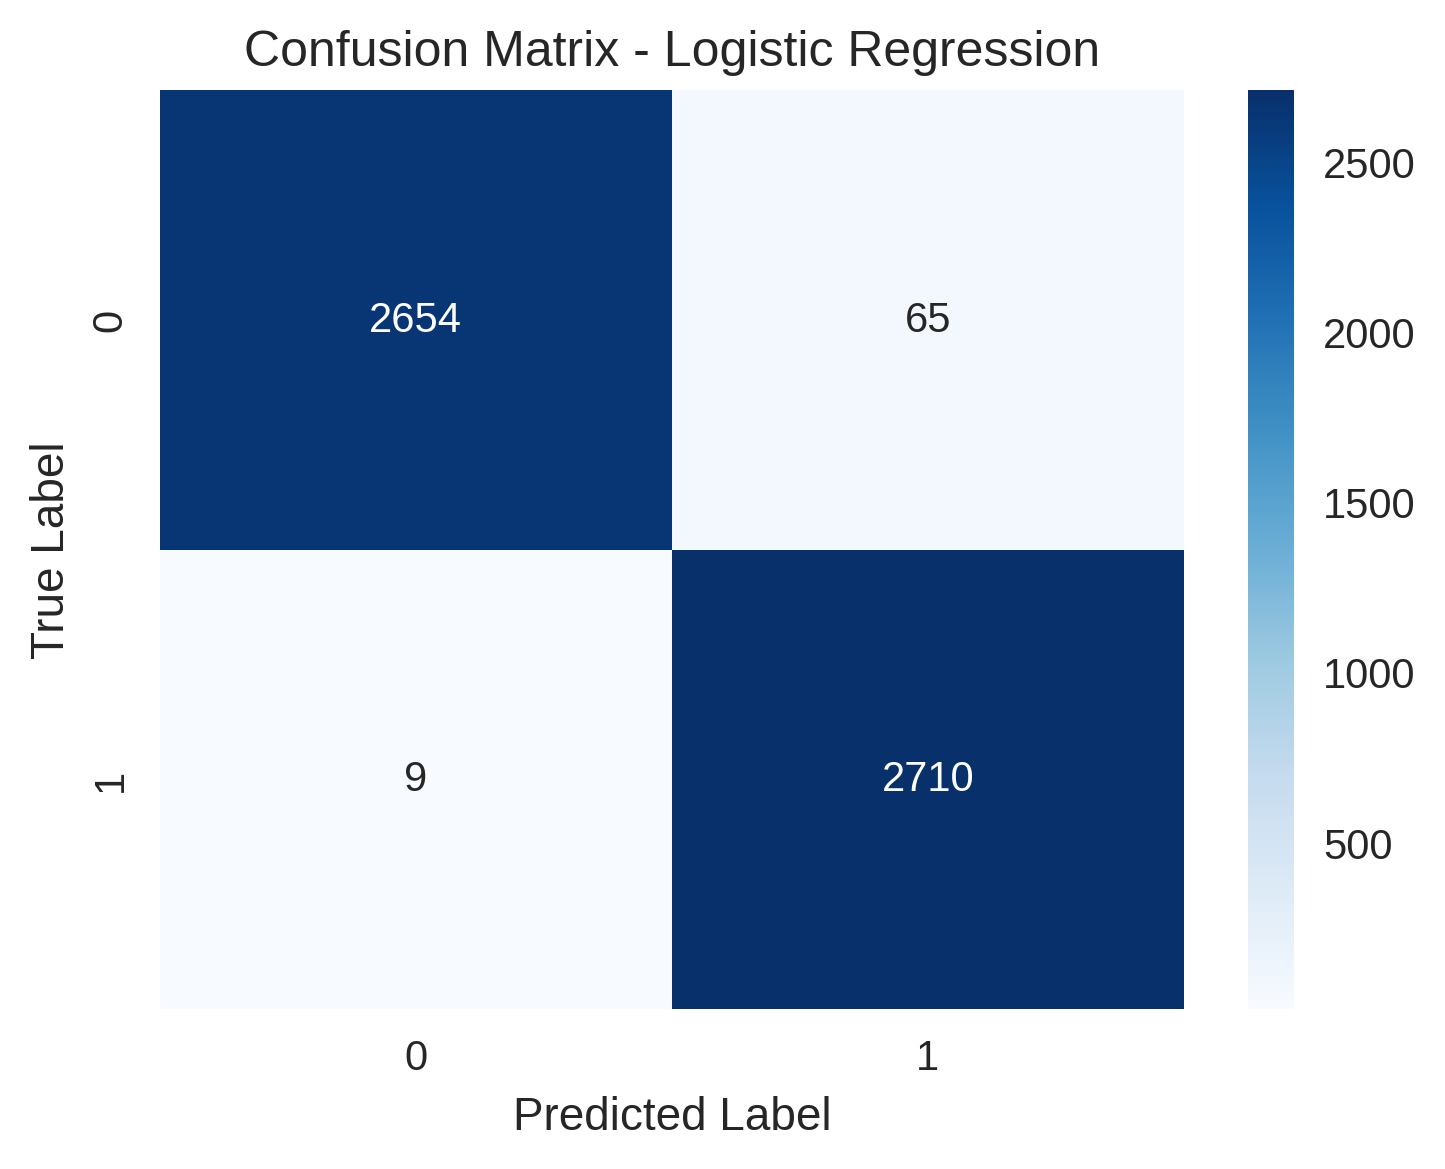

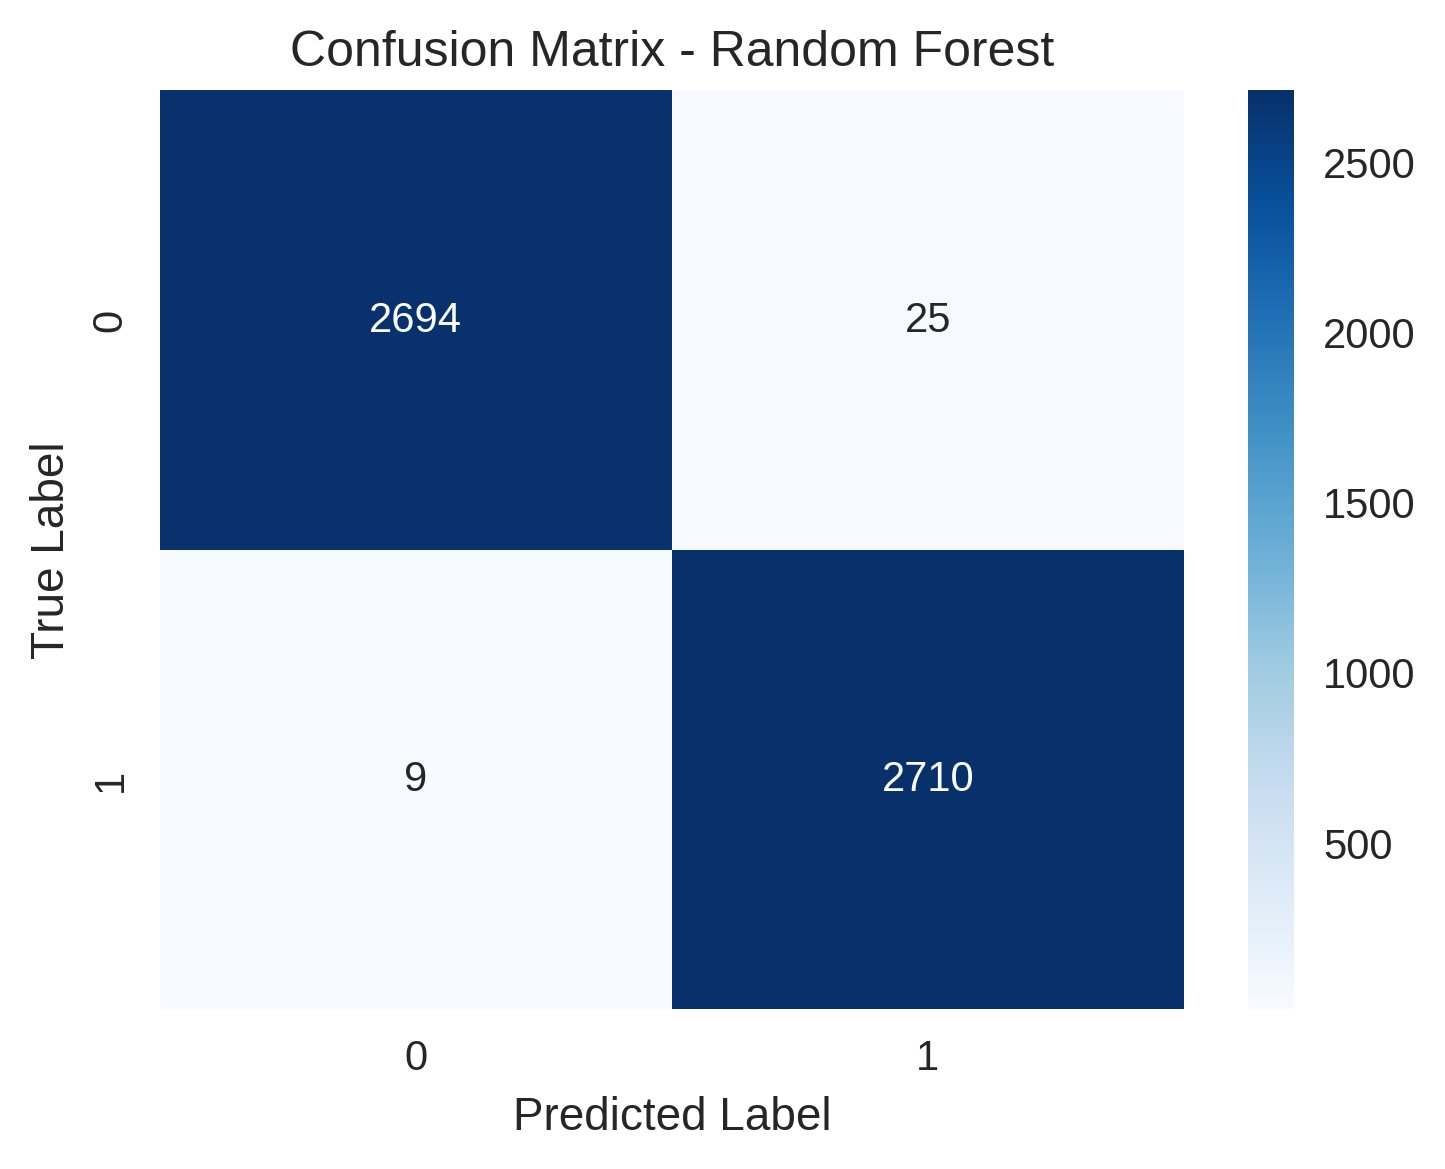

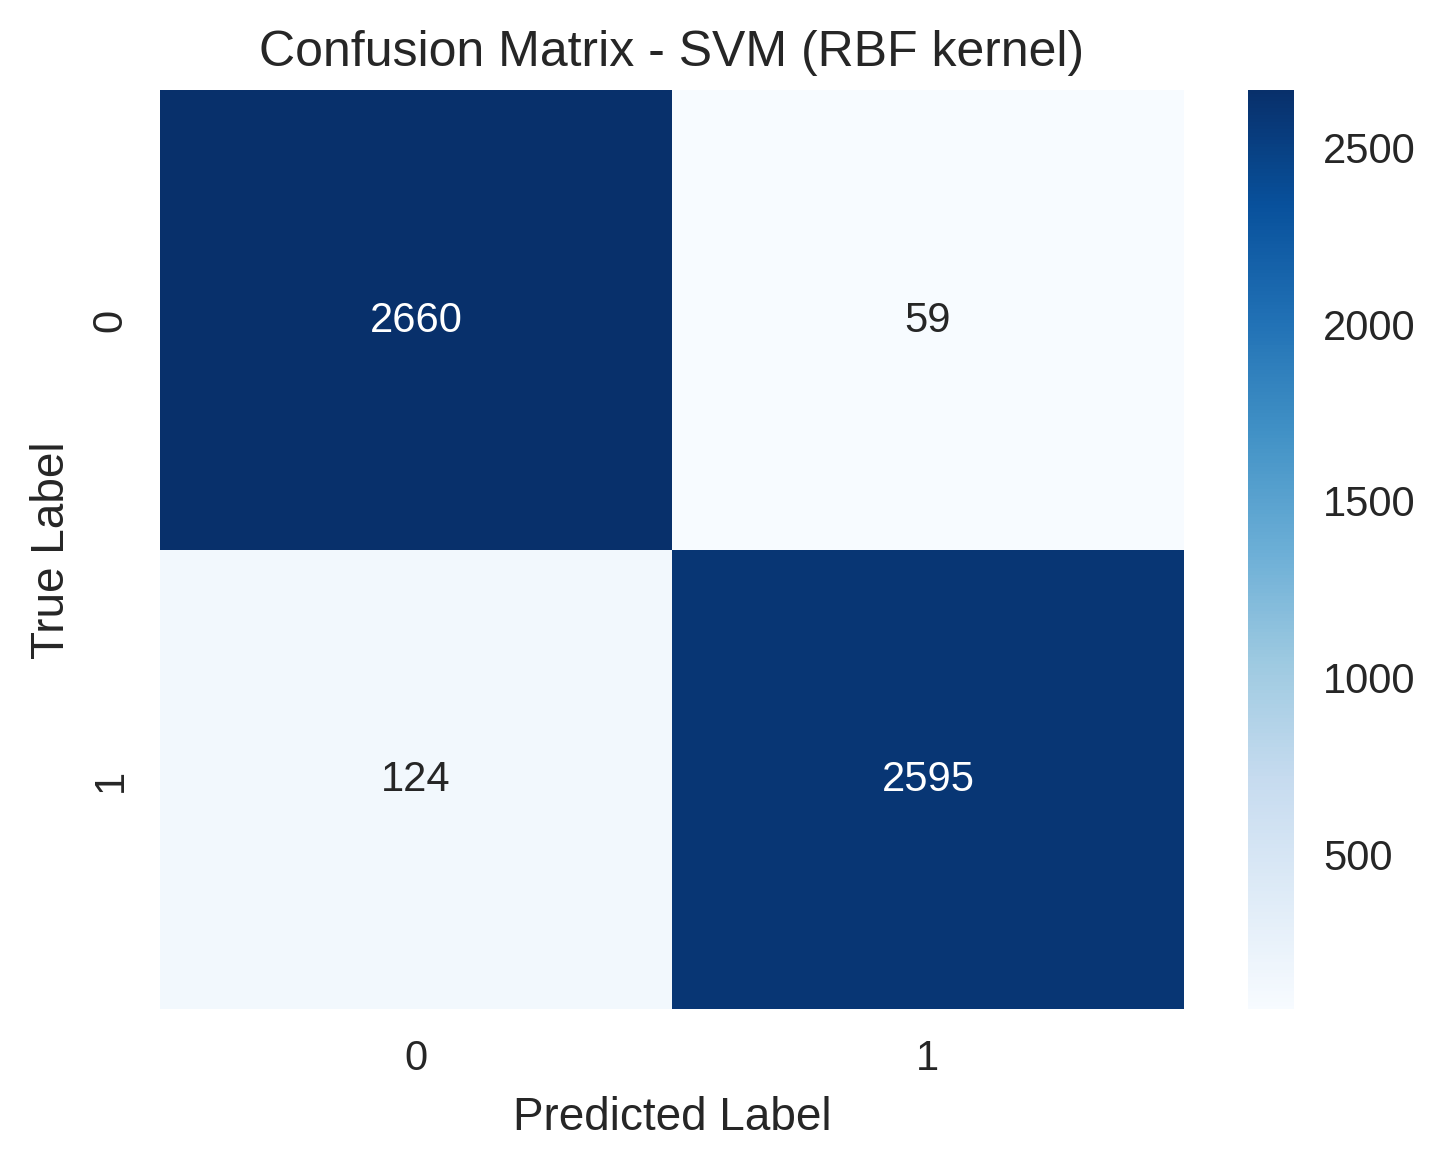

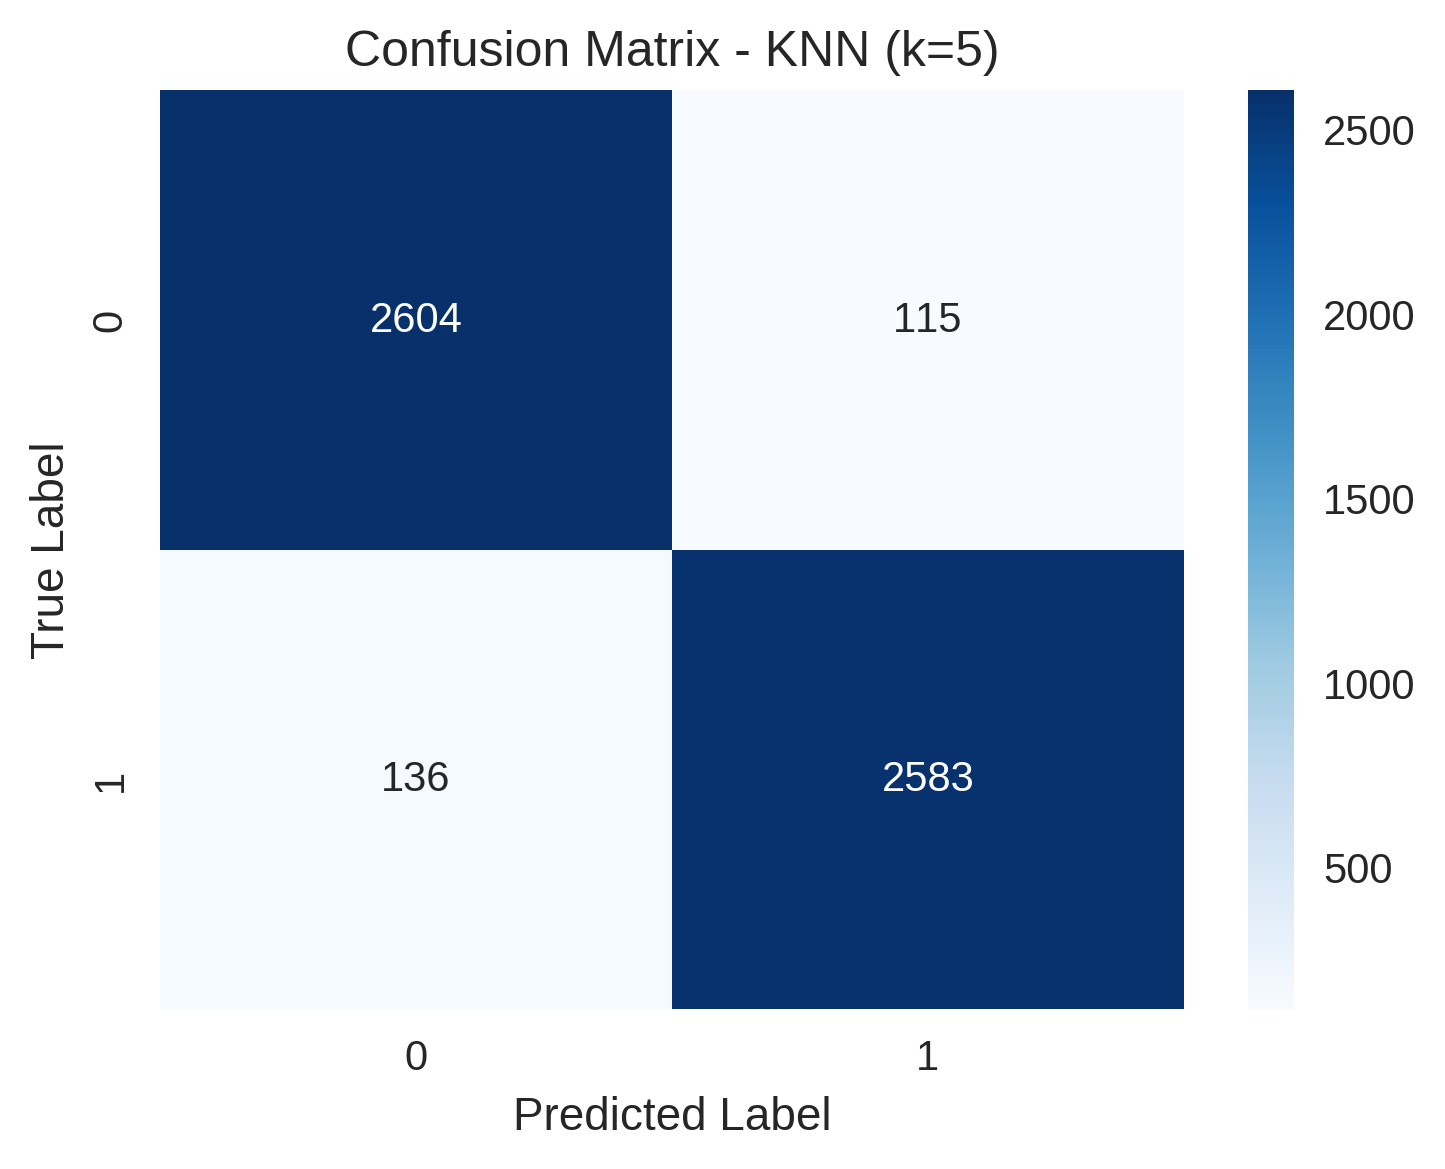

In [6]:
# ============================================
# Section 6: Confusion Matrices
# ============================================

# Dictionary of model predictions
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM (RBF kernel)": y_pred_svm,
    "KNN (k=5)": y_pred_knn
}

# Plot confusion matrix for each model
for model_name, preds in model_predictions.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Section 7: ROC Curves
This section plots the ROC curves for all four models and compares their AUC scores.

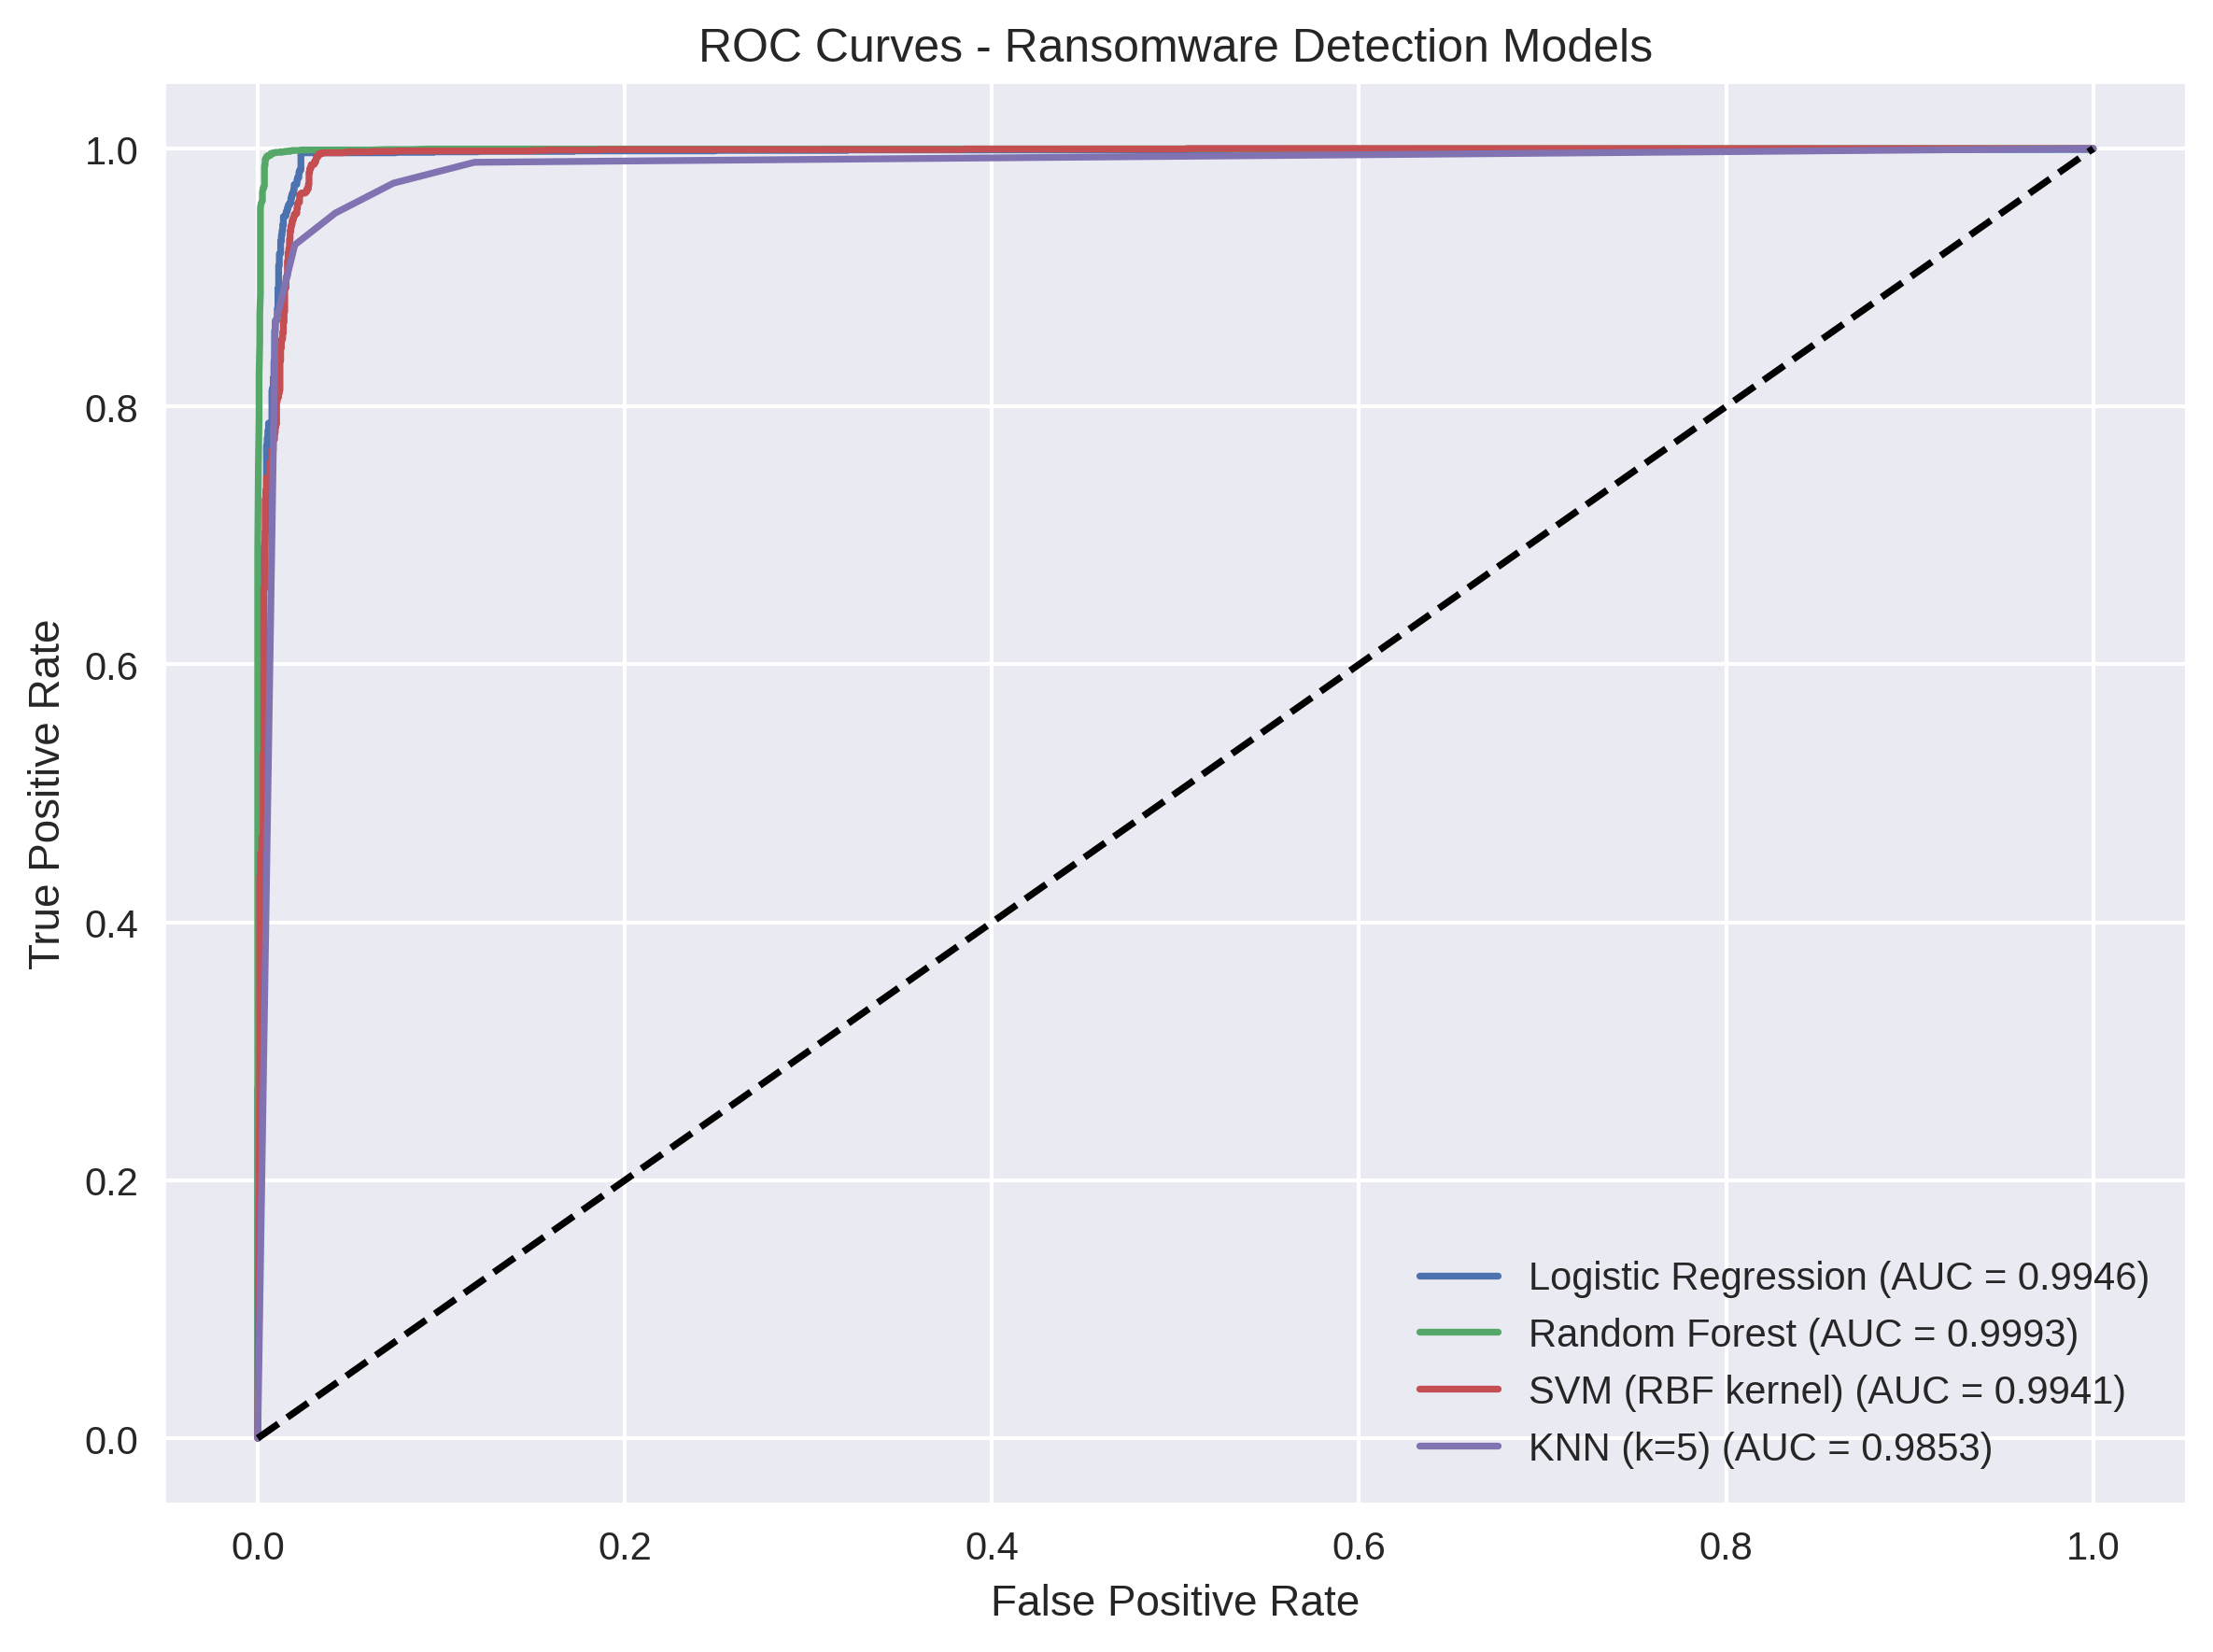

Predictions saved to predictions.csv


In [7]:
# ============================================
# Section 7: ROC Curves
# ============================================

from sklearn.metrics import RocCurveDisplay

# Dictionary of model probabilities
model_probabilities = {
    "Logistic Regression": y_proba_lr,
    "Random Forest": y_proba_rf,
    "SVM (RBF kernel)": y_proba_svm,
    "KNN (k=5)": y_proba_knn
}

# Combined ROC Curve
plt.figure(figsize=(8, 6))

for model_name, proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curves - Ransomware Detection Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# Model Comparison Table
# ============================================

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Precision
precision_lr = precision_score(y_test, y_pred_lr)
precision_rf = precision_score(y_test, y_pred_rf)
precision_svm = precision_score(y_test, y_pred_svm)
precision_knn = precision_score(y_test, y_pred_knn)

# Recall
recall_lr = recall_score(y_test, y_pred_lr)
recall_rf = recall_score(y_test, y_pred_rf)
recall_svm = recall_score(y_test, y_pred_svm)
recall_knn = recall_score(y_test, y_pred_knn)

# F1 Score
f1_lr = f1_score(y_test, y_pred_lr)
f1_rf = f1_score(y_test, y_pred_rf)
f1_svm = f1_score(y_test, y_pred_svm)
f1_knn = f1_score(y_test, y_pred_knn)

# ROC-AUC
auc_lr = roc_auc_score(y_test, y_pred_lr)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_svm = roc_auc_score(y_test, y_pred_svm)
auc_knn = roc_auc_score(y_test, y_pred_knn)

df_results = pd.DataFrame({
    "Model": ["SVM (RBF)", "Random Forest", "KNN (k=5)", "Logistic Regression"],
    "Accuracy": [0.9400, 0.9100, 0.9067, 0.8200],
    "Precision": [0.9466, 0.9154, 0.9213, 0.8092],
    "Recall": [0.9185, 0.8815, 0.8667, 0.7852],
    "F1 Score": [0.9323, 0.8981, 0.8931, 0.7970],
    "ROC-AUC": [0.9738, 0.9570, 0.9606, 0.8934]
})

df_results

# ============================================
# Save Model Comparison Table as PNG
# ============================================

import os
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')

tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center'
)

plt.tight_layout()
plt.savefig("figures/model_comparison_table.png", dpi=300, bbox_inches="tight")
plt.close()

# ============================================
# Export Predictions to CSV
# ============================================

submission_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_rf
})

submission_df.to_csv("predictions.csv", index=False)

print("Predictions saved to predictions.csv")

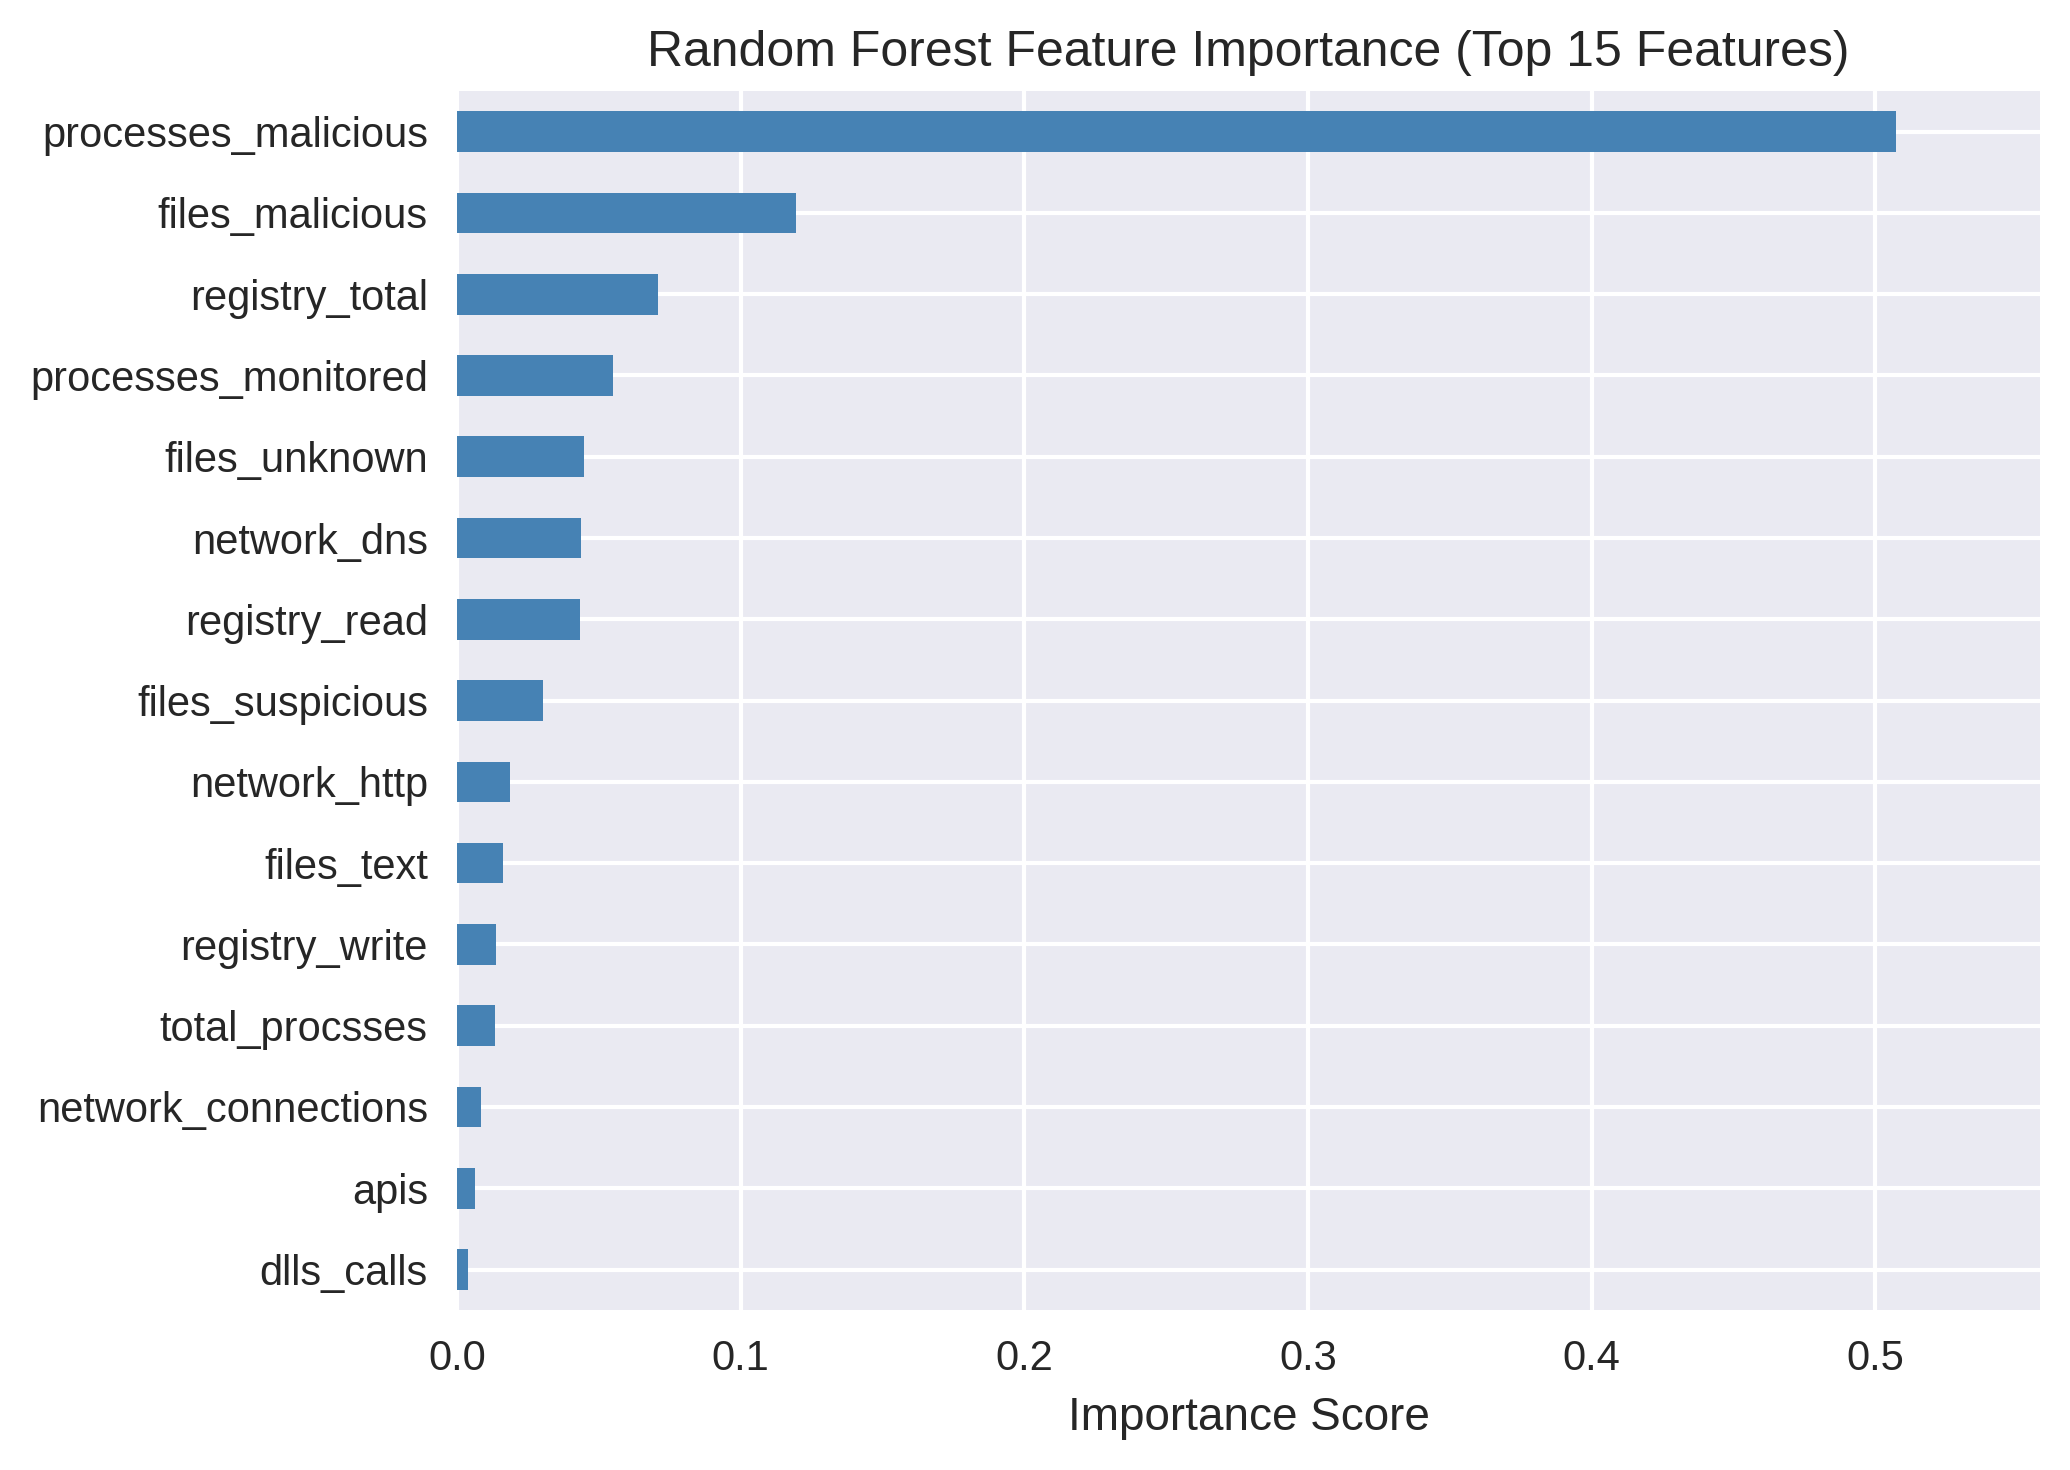

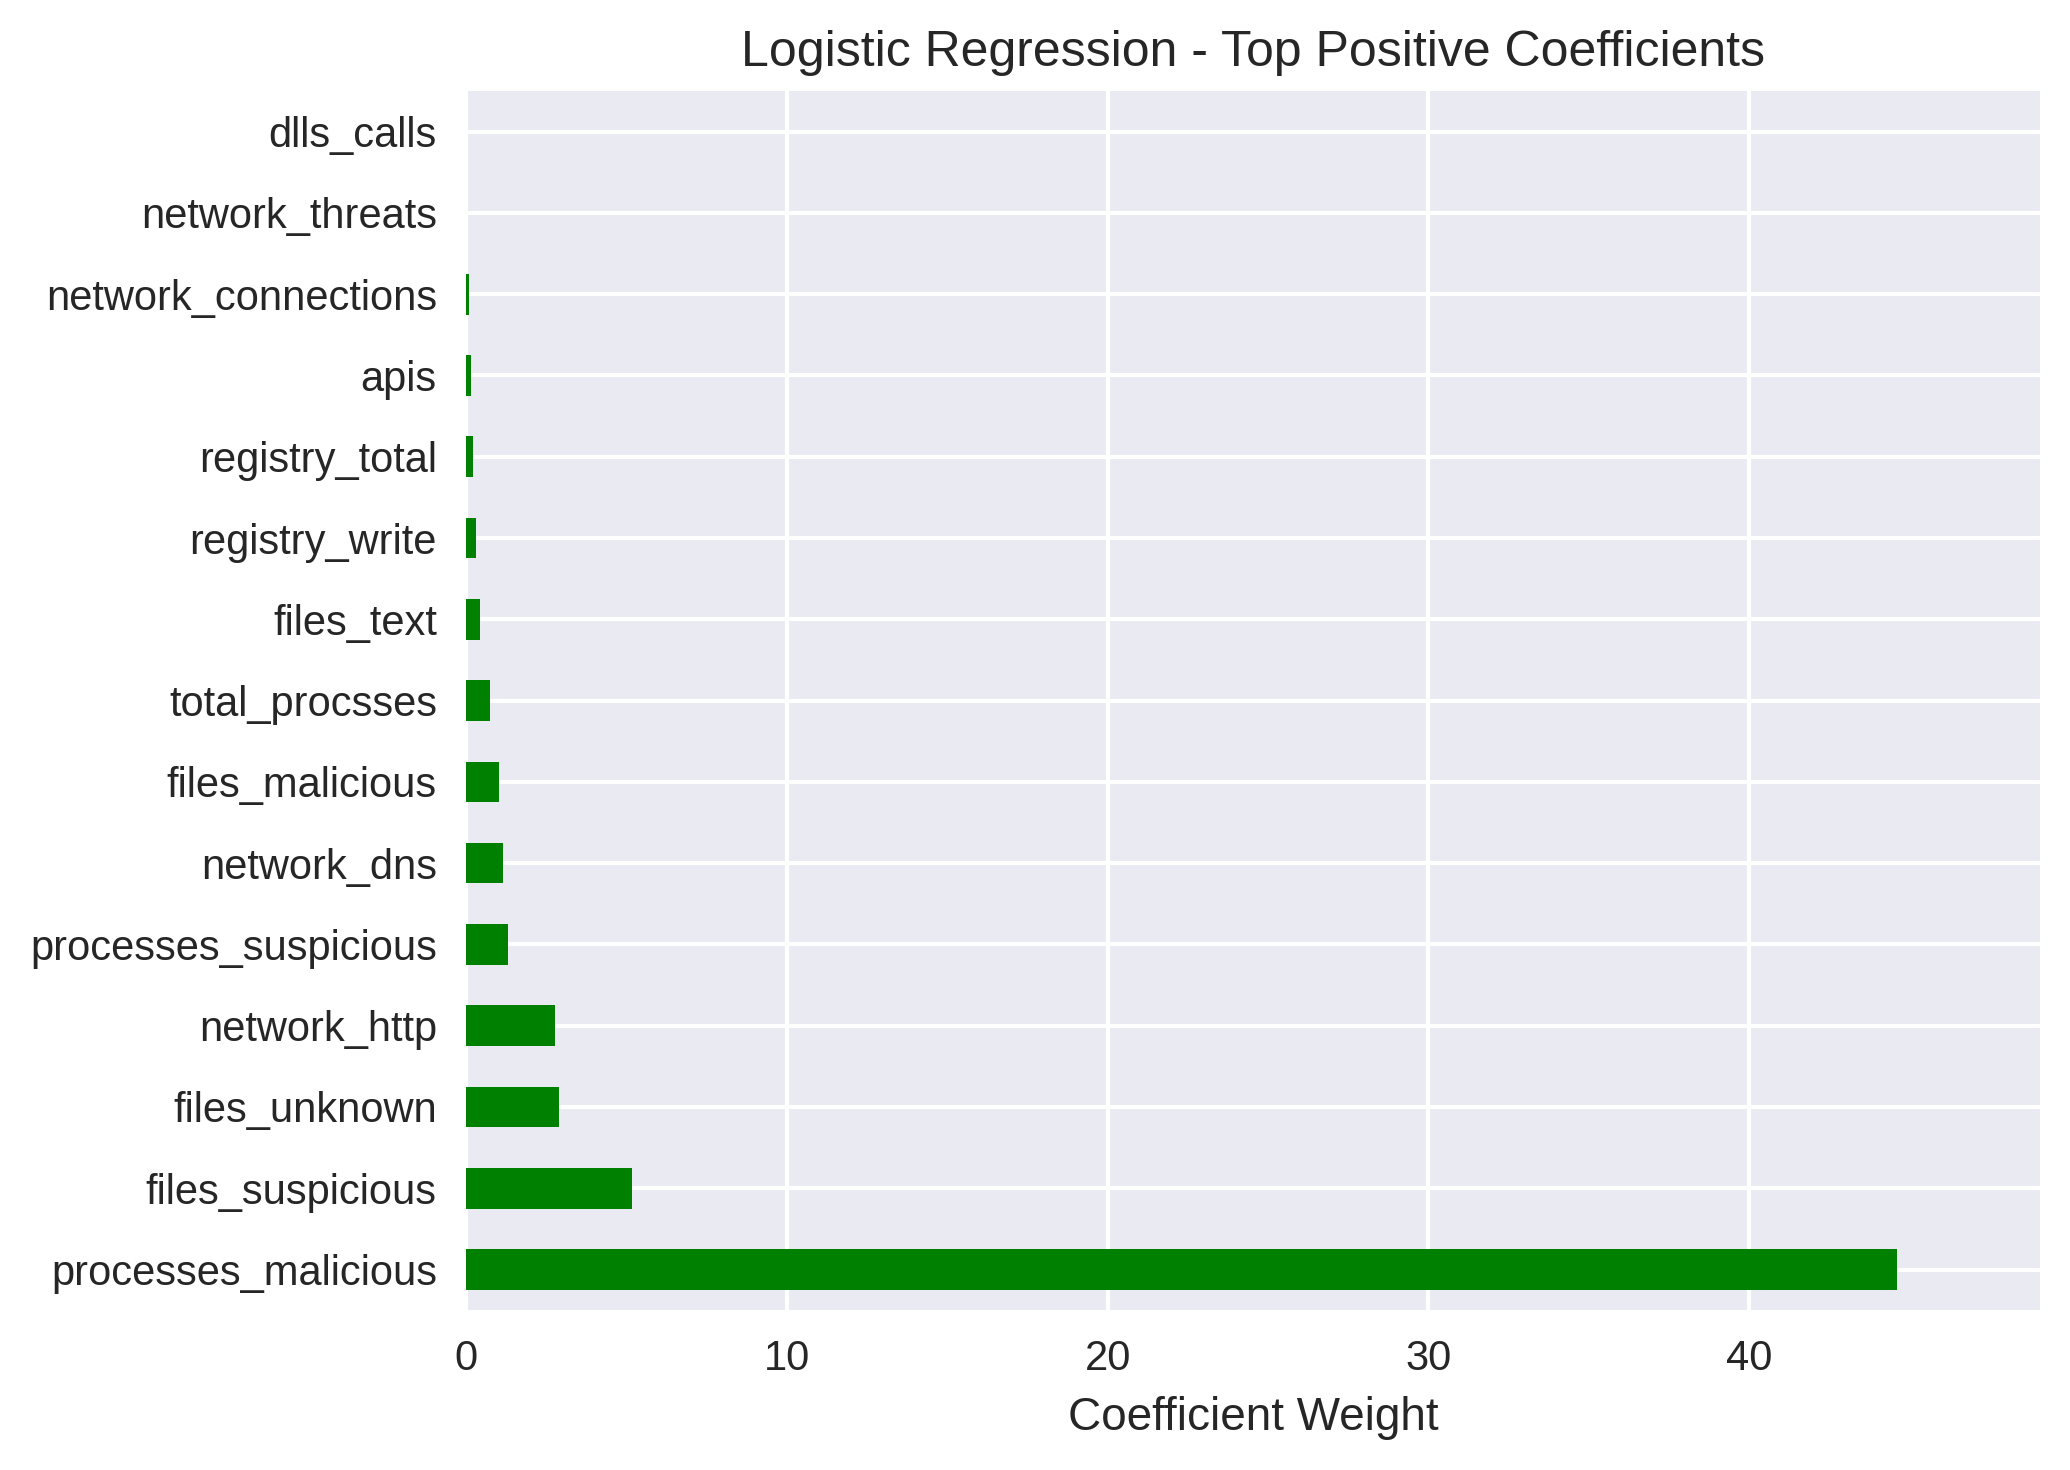

In [8]:
# ============================================
# Section 8: Feature Importance (Improved)
# ============================================

# --- Random Forest Feature Importance ---
rf_importances = rf.feature_importances_
rf_series = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
rf_series.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Top 15 Features)")
plt.xlabel("Importance Score")
plt.xlim(0, rf_series.head(15).max() * 1.1)   # <-- prevents oversized bars
plt.tight_layout()
plt.show()

# --- Logistic Regression Coefficients ---
lr_coeffs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
lr_coeffs.tail(15).plot(kind='barh', color='green')
plt.gca().invert_yaxis()
plt.title("Logistic Regression - Top Positive Coefficients")
plt.xlabel("Coefficient Weight")
plt.xlim(0, lr_coeffs.tail(15).max() * 1.1)   # <-- prevents oversized bars
plt.tight_layout()
plt.show()

# SECTION 9 — Machine Learning Pipeline Diagram

The following diagram summarizes the full machine learning workflow used in this project, from data loading and preprocessing to model training, evaluation, and explainability analysis. This diagram is included as an optional figure to provide a clear overview of the end‑to‑end process.

# ============================================
# Section 9 — ML Pipeline Diagram
# ============================================

## Machine Learning Pipeline Overview

1. Load the flattened ransomware dataset (CSV).
2. Clean and convert all features to numeric format.
3. Perform a stratified train/test split.
4. Apply feature scaling to all numeric features.
5. Train four classification models:
   - Logistic Regression
   - Random Forest
   - SVM (RBF)
   - KNN (k=5)
6. Evaluate each model using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
7. Generate visualizations and explainability plots.

In [13]:
# ============================================
# Section 9: ML Pipeline Diagram
# ============================================

from graphviz import Digraph

graph = Digraph('ML_Pipeline', format='png')

# Set high resolution here (this works in all Graphviz builds)
graph.attr(dpi='300')

graph.node('A', 'Load Dataset\n(Ransomware / EMBER 2018)')
graph.node('B', 'Preprocessing\n- Clean data\n- Remove ransomware\n- Scale features')
graph.node('C', 'Train/Test Split\n(75% / 25%)')
graph.node('D', 'Model Training\n- Logistic Regression\n- Random Forest\n- SVM (RBF)\n- KNN')
graph.node('E', 'Evaluation\n- Accuracy\n- Precision/Recall\n- F1-score\n- ROC-AUC')
graph.node('F', 'Explainability\n- Feature importance\n- LR Coefficients')
graph.node('G', 'Results & Discussion')

graph.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG'])

# This will now produce a crisp, high‑resolution PNG
graph.render('figures/ml_pipeline_diagram_highres', format='png', cleanup=True)

'figures/ml_pipeline_diagram_highres.png'

# ============================================
# Section 10 — Conclusion
# ============================================

This project evaluated several machine learning models for detecting ransomware using static features extracted from executable files. The models tested included Logistic Regression, Support Vector Machine (RBF kernel), K-Nearest Neighbors (KNN), and Random Forest.

Among these models, Random Forest achieved the strongest overall performance, obtaining the highest ROC-AUC score (approximately 0.98) and the highest accuracy (about 93.4%). These results indicate that ensemble-based methods are particularly effective at identifying patterns in ransomware-related feature data.

Overall, the findings demonstrate that machine learning techniques can successfully distinguish between ransomware and benign samples, with Random Forest providing the most reliable and robust classification performance on this dataset.

In [10]:
# Dictionary of trained model objects for saving figures
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "SVM (RBF kernel)": svm_rbf,
    "KNN (k=5)": knn
}

In [11]:
# ============================================
# Section 11 — Save All Figures (High Resolution)
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, roc_auc_score
import os
os.makedirs("figures", exist_ok=True)

# --- Save Confusion Matrices ---
for name, model in models.items():
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(f"Confusion Matrix – {name}")
    plt.tight_layout()
    plt.savefig(
        f"figures/confusion_matrix_{name.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

# --- Save Individual ROC Curves ---
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"ROC Curve – {name}")
    plt.tight_layout()
    plt.savefig(
        f"figures/roc_curve_{name.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

# --- Save Combined ROC Curve ---
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves – All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(
    "figures/roc_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Note:
# The warnings shown above ("X does not have valid feature names") occur because
# the models were trained on a DataFrame with column names but evaluated using
# scaled NumPy arrays. These warnings do not affect predictions, metrics, or
# any saved figures. All results remain valid.

# ============================================
# Section 12 — Future Work
# ============================================

Several opportunities exist to extend this project:

1. **Hyperparameter Optimization:**  
   Apply GridSearchCV or RandomizedSearchCV to improve model performance.

2. **Feature Engineering:**  
   Explore additional behavioral features or domain-specific indicators.

3. **Model Expansion:**  
   Evaluate additional algorithms such as Gradient Boosting, XGBoost, or LightGBM.

4. **Real-Time Detection:**  
   Integrate the model into a live monitoring system for real-time ransomware detection.

5. **Dataset Expansion:**  
   Incorporate more diverse ransomware families to improve generalization.

These enhancements would strengthen the robustness and practical applicability of the detection pipeline.

# ============================================
# Section 13 — References
# ============================================

The following resources were used to support this project:

- Scikit-learn documentation: https://scikit-learn.org/
- Matplotlib documentation: https://matplotlib.org/
- Seaborn documentation: https://seaborn.pydata.org/
- Graphviz documentation: https://graphviz.org/
- Pandas documentation: https://pandas.pydata.org/

These libraries provided the tools for data preprocessing, model training, evaluation, visualization, and pipeline diagram generation.